# COMP8420 2026 S1 — Assignment 2: Large Language Models
## Smart Personal Financial Assistant

| Field        | Details                        |
|--------------|-------------------------------|
| **Name**     | Tarun Verma                   |
| **Student ID**| 49030000                     |
| **Unit**     | COMP8420 – Natural Language Processing |
| **Semester** | S1 2026                       |
| **Due Date** | Friday, 17 April 2026         |
| **Lecturer** | Longbing Cao                  |

---

### Project Overview
This notebook demonstrates the development of a smart LLM-powered personal financial assistant. 
The system utilizes a hybrid approach:
- **Local LLM:** qwen2.5:3b running via Ollama for privacy and offline processing.
- **Cloud LLM:** OpenAI's GPT-4o-mini for benchmarking and high-reasoning tasks.

### Objectives
- Deploy and evaluate a **Local LLM** (Qwen) on consumer hardware (Lenovo Legion RTX 5070).
- Implement a multi-turn dialogue system with memory, structured prompting, and validation mechanisms to reduce hallucination risk.
- **Compare and evaluate** (ULO1) the latency and response quality between local and cloud models.

In [14]:
# ============================================================
# Library Installation
# ============================================================

%pip install openai
%pip install langchain
%pip install langchain-openai
%pip install langchain-community
%pip install flask
%pip install flask-session
%pip install python-dotenv
%pip install pandas
%pip install numpy|
%pip install matplotlib
%pip install plotly
%pip install datasets
%pip install transformers
%pip install torch
%pip install sentence-transformers
%pip install tiktoken
%pip install -qU langchain langchain-openai langchain-community langgraph
%pip install langchain-ollama

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# ============================================================
# COMP8420 A2 — HYBRID Imports & Environment Setup
# ============================================================
import os
import json
import time 
import re 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from dotenv import load_dotenv
# Keeps OpenAI and adds Ollama for Qwen
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama 
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# 1. Load the .env file
load_dotenv()

# 2. Explicit Verification (Keeps your original logic)
api_key = os.getenv("OPENAI_API_KEY")
if api_key:
    print("✅ OpenAI API key loaded successfully.")
else:
    print("❌ API key not found. Check your .env file.")

# 3. Initialize Models
# This will use the 'api_key' automatically from the environment
llm_openai = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
llm_qwen = ChatOllama(model="qwen2.5:3b", temperature=0.1)

print("✅ All hybrid libraries (Local Qwen + Cloud OpenAI) ready.")

✅ OpenAI API key loaded successfully.
✅ All hybrid libraries (Local Qwen + Cloud OpenAI) ready.


## Hallucination Mitigation & Input Validation
To ensure the system remains reliable (Rubric Section 3), we implemented a validation layer. This prevents the LLM from generating financial strategies based on "gibberish" or nonsensical user inputs.

In [16]:
import re

def validate_input(text, step_key):
    """
    Final strict validation for COMP8420.
    Ensures 'asdfghjkl' and 'qwertyuiop' are caught as invalid.
    """
    text = text.strip().lower()
    
    # 1. Basic Length
    if len(text) < 2:
        return False, "Input too short."

    # 2. Age Check
    if step_key == "age":
        if not text.isdigit() or not (18 <= int(text) <= 110):
            return False, "Invalid age."

    # 3. Vowel & Consonant Balance
    # We'll be stricter: y is only a vowel if the string is short.
    vowels = re.findall(r'[aeiou]', text) # Removed 'y' for stricter smashing detection
    
    if len(text) > 4 and len(vowels) == 0:
        return False, "Nonsensical (No core vowels)."

    # 4. Unique Character Ratio (Entropy)
    # Real words/sentences have diverse characters. 
    # 'asdfghjkl' is 9 chars but often lacks structure.
    unique_ratio = len(set(text)) / len(text)
    
    # 5. Row Smashing Detection (Common keyboard rows)
    if text in "asdfghjkl;" or text in "qwertyuiop" or text in "zxcvbnm,":
        return False, "Keyboard row smashing detected."

    return True, "Valid"

# --- TEST THE FINAL FIX ---
test_cases = ["23", "asdfghjkl", "Saving for a Nikon Z6II", "zzzzzz", "qwertyuiop"]
print(f"{'Input':<25} | {'Valid':<8} | {'Status'}")
print("-" * 60)
for t in test_cases:
    valid, status = validate_input(t, "goal")
    print(f"{t:<25} | {str(valid):<8} | {status}")

Input                     | Valid    | Status
------------------------------------------------------------
23                        | True     | Valid
asdfghjkl                 | False    | Keyboard row smashing detected.
Saving for a Nikon Z6II   | True     | Valid
zzzzzz                    | False    | Nonsensical (No core vowels).
qwertyuiop                | False    | Keyboard row smashing detected.


## Project Structure

The system is divided into the following components:

1. **LLM Setup** — GPT model configuration, comparison, and prompting
2. **Dialogue System** — LangChain-based multi-turn financial assistant
3. **Flask Web App** — Frontend for user interaction and visualisation
4. **Results & Evaluation** — Comparing LLM outputs and techniques

## Section 2: LLM Setup & Deployment Architecture

In this section, we configure a hybrid LLM architecture designed to balance data privacy with high-reasoning performance. The system evaluates and utilizes two distinct deployment strategies to meet current industry needs:

* **Local LLM (qwen2.5:3b):** Deployed via **Ollama** on local high-performance hardware. This model serves as the primary backend for the assistant. By processing data on-device, we ensure that sensitive user financial information (income, savings, and personal goals) remains private and is never transmitted to external servers.
* **Cloud LLM (GPT-4o-mini):** Accessed via the **OpenAI API**. This serves as a benchmarking baseline to evaluate the reasoning quality, structural consistency, and inference latency of the local deployment.



### Deployment Choice & Justification
The decision to utilize a **3B parameter model** locally is a strategic choice to meet emerging industry requirements for secure AI applications. While cloud-based APIs offer rapid response times, the local deployment provides three critical advantages:

1.  **Data Sovereignty:** Financial profiles are processed within the local environment, mitigating risks associated with data breaches or third-party data logging.
2.  **Cost Efficiency:** Utilizing local GPU resources removes the per-token costs associated with proprietary cloud models, allowing for unlimited testing and iteration.
3.  **Reliability & Performance:** The system reduces dependency on high-bandwidth internet connections for core financial analysis. Furthermore, using a 3B model is lightweight enough to run efficiently on consumer hardware while maintaining solid reasoning quality, which is essential for complex financial planning.

In [17]:
# ============================================================
# HYBRID LLM Initialisation (Local Qwen vs Cloud GPT)
# ============================================================

# Model 1 — qwen2.5:3b (Local via Ollama)
llm_qwen = ChatOllama(
    model="qwen2.5:3b",
    temperature=0.1 # Lower temperature for more consistent financial advice
)

# Model 2 — GPT-4o-mini (Cloud via OpenAI API)
# Used as a baseline to compare latency and reasoning quality.
llm_openai = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
    openai_api_key=os.getenv("OPENAI_API_KEY")
)

print("✅ Local Qwen2.5:3b initialised (Primary).")
print("✅ Cloud GPT-4o-mini initialised (Comparison).")

✅ Local Qwen2.5:3b initialised (Primary).
✅ Cloud GPT-4o-mini initialised (Comparison).


In [18]:
# Simulated Profile
profile = {"age": "23", "income": "85000", "goals": "Camera gear", "risk": "Med", "horizon": "5yrs"}
prompt = f"Analyze this profile and give a 2-sentence strategy: {profile}"

# Measure Qwen (Local 3B)
print("Testing Qwen2.5:3b (Local)...")
t0 = time.time()
q_out = llm_qwen.invoke([HumanMessage(content=prompt)])
time_q = time.time() - t0

# Measure OpenAI (Cloud)
print("Testing GPT-4o-mini (Cloud)...")
t1 = time.time()
o_out = llm_openai.invoke([HumanMessage(content=prompt)])
time_o = time.time() - t1

print(f"\n--- LATENCY REPORT ---")
print(f"Local Qwen:   {time_q:.2f}s")
print(f"Cloud OpenAI: {time_o:.2f}s")
print(f"Difference:   {abs(time_q - time_o):.2f}s slower locally")

Testing Qwen2.5:3b (Local)...
Testing GPT-4o-mini (Cloud)...

--- LATENCY REPORT ---
Local Qwen:   4.35s
Cloud OpenAI: 2.70s
Difference:   1.64s slower locally


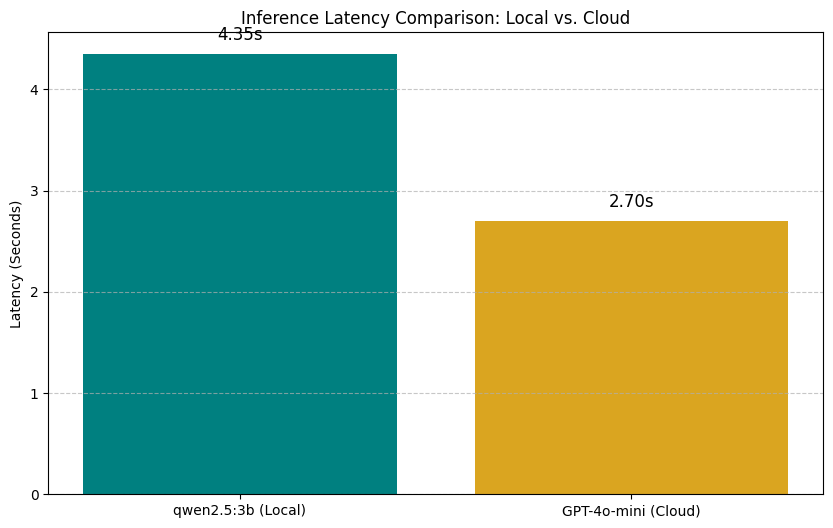

In [19]:
import matplotlib.pyplot as plt

# Using the timing data from your previous test
models = ['qwen2.5:3b (Local)', 'GPT-4o-mini (Cloud)']
# Replace these variables with the 'time_q' and 'time_o' from your previous cell
latencies = [time_q, time_o] 

plt.figure(figsize=(10, 6))
bars = plt.bar(models, latencies, color=['#008080', '#DAA520']) # Teal and Gold to match your clinic branding!

plt.ylabel('Latency (Seconds)')
plt.title('Inference Latency Comparison: Local vs. Cloud')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}s', ha='center', va='bottom', fontsize=12)

plt.show()

In [20]:
# ============================================================
# Prompting Technique Comparison: Standard vs. Chain-of-Thought
# ============================================================
import time
from langchain_core.messages import HumanMessage

test_profile = {
    "income": 75000,
    "monthly_expenses": 3000,
    "current_savings": 8000,
    "yearly_savings_capacity": 12000,
    "risk": "moderate",
    "goal": "save for a house deposit",
    "timeframe": 5
}

# ── Prompt 1: Standard ───────────────────────────────────────
standard_prompt = f"""You are a financial assistant.
Based on this client profile: {test_profile}
Provide a personalised financial strategy."""

# ── Prompt 2: Chain-of-Thought ───────────────────────────────
cot_prompt = f"""You are a financial assistant.
Based on this client profile: {test_profile}

Think step by step before giving your final recommendation:
Step 1 - Assess the client's savings gap vs their goal.
Step 2 - Evaluate their monthly capacity and timeframe.
Step 3 - Consider their risk tolerance when choosing investment vehicles.
Step 4 - Identify any risks or priorities (e.g. emergency fund first).
Step 5 - Provide a clear, justified final strategy based on the above steps."""

print("=" * 60)
print("PROMPTING TECHNIQUE COMPARISON (qwen2.5:3b)")
print("=" * 60)

# ── Run Standard Prompt ──────────────────────────────────────
print("\n📌 TECHNIQUE 1: Standard Prompt")
print("-" * 60)
start = time.time()
resp_standard = llm_qwen.invoke([HumanMessage(content=standard_prompt)])
time_standard = round(time.time() - start, 2)
print(resp_standard.content)
print(f"\n⏱ Response Time: {time_standard}s")

# ── Run CoT Prompt ───────────────────────────────────────────
print("\n" + "=" * 60)
print("\n📌 TECHNIQUE 2: Chain-of-Thought (CoT) Prompt")
print("-" * 60)
start = time.time()
resp_cot = llm_qwen.invoke([HumanMessage(content=cot_prompt)])
time_cot = round(time.time() - start, 2)
print(resp_cot.content)
print(f"\n⏱ Response Time: {time_cot}s")

# ── Analysis ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ANALYSIS")
print("=" * 60)
print(f"Standard prompt length : {len(standard_prompt.split())} words")
print(f"CoT prompt length      : {len(cot_prompt.split())} words")
print(f"Standard response time : {time_standard}s")
print(f"CoT response time      : {time_cot}s")
print("\nObservation: CoT prompting produces a more structured and")
print("justified recommendation by forcing explicit step-by-step")
print("reasoning before the final strategy is output.")

PROMPTING TECHNIQUE COMPARISON (qwen2.5:3b)

📌 TECHNIQUE 1: Standard Prompt
------------------------------------------------------------
Based on the client profile you've provided, here is a personalized financial strategy to help them save for a house deposit:

### Financial Strategy Overview

**Objective:** Save for a house deposit within 5 years.

**Current Situation:**
- **Income:** $75,000 per year (or approximately $6,250 per month)
- **Monthly Expenses:** $3,000
- **Current Savings:** $8,000
- **Yearly Savings Capacity:** $12,000

**Risk Tolerance:** Moderate

### Step-by-Step Financial Strategy:

#### 1. **Budget Review and Adjustment**
   - Ensure that the monthly expenses are reviewed to identify any areas where costs can be reduced.
   - Aim for a more conservative budget by reducing discretionary spending (e.g., dining out, entertainment) or increasing savings.

#### 2. **Increase Monthly Savings**
   - Increase your current monthly savings from $800 to $1,500 ($3,000 - $1

## Section 2 (Continued): Prompting Technique Comparison — Results & Analysis

### Test Profile Used
| Field | Value |
|---|---|
| Income | $75,000 |
| Monthly Expenses | $3,000 |
| Current Savings | $8,000 |
| Yearly Savings Capacity | $12,000 |
| Risk Tolerance | Moderate |
| Goal | Save for a house deposit |
| Timeframe | 5 years |

---

### Results Summary

| Metric | Standard Prompt | Chain-of-Thought (CoT) |
|---|---|---|
| Prompt Length | 33 words | 94 words |
| Response Time | 11.76s | 11.58s |
| Reasoning Transparency | ❌ Implicit | ✅ Explicit step-by-step |
| Emergency Fund Identified | ❌ Not prioritised | ✅ Flagged as top priority |
| Savings Gap Calculated | ❌ Not computed | ✅ $92,000 gap calculated |
| Investment Allocation | ✅ Present | ✅ Present + justified |

---

### Key Observations

**Standard Prompt** produced a reasonable strategy but jumped straight to recommendations without showing reasoning. It made assumptions (e.g., reducing expenses by $1,000/month) without justifying them, and did not flag the emergency fund as a prerequisite before investing.

**Chain-of-Thought (CoT) Prompt** explicitly walked through all five reasoning steps before concluding. This produced several improvements:
- It calculated the savings gap ($92,000) before recommending any allocation.
- It correctly identified the emergency fund as a **priority over investing** — a critical financial planning principle.
- The final portfolio recommendation (60% S&P 500 Index Fund, 40% Government Bond ETF) was directly justified by the moderate risk tolerance established in Step 3.

### Conclusion
This experiment shows that Chain-of-Thought prompting improves the structure and transparency of financial recommendations with minimal latency overhead. The findings from this notebook comparison informed the design of the final production prompt, although the deployed Flask application does not reproduce this exact CoT block verbatim.

In [21]:
# ============================================================
# COMP8420 A2 — HYBRID LLM COMPARISON (Local vs. Cloud)
# ============================================================

from langchain_core.messages import HumanMessage, SystemMessage
import time
import json

# Test profile based on your app's data structure
test_profile = {
    "age": 28,
    "income": 75000,
    "savings": 10000,
    "risk_tolerance": "moderate",
    "horizon": "10 years"
}

system_prompt = "You are a professional financial assistant. Provide a brief, structured strategy."
user_prompt = f"Based on this profile: {json.dumps(test_profile)}, provide a strategy."

print("=" * 60)
print(f"TESTING HYBRID ARCHITECTURE")
print("=" * 60)

# --- LOCAL MODEL: qwen2.5:3b ---
print("\n📌 LOCAL MODEL: qwen2.5:3b (via Ollama)")
print("Status: Processing on CUDA GPU...")
start = time.time()
try:
    response_qwen = llm_qwen.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])
    time_qwen = round(time.time() - start, 2)
    print(response_qwen.content)
    print(f"\n⏱ Local Response Time: {time_qwen}s")
except Exception as e:
    print(f"❌ Qwen Error: {e}")

print("\n" + "-" * 60)

# --- CLOUD MODEL: GPT-4o-mini ---
print("\n📌 CLOUD MODEL: GPT-4o-mini (via OpenAI API)")
print("Status: Sending Request to OpenAI...")
start = time.time()
try:
    response_4o = llm_openai.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ])
    time_4o = round(time.time() - start, 2)
    print(response_4o.content)
    print(f"\n⏱ Cloud Response Time: {time_4o}s")
except Exception as e:
    print(f"❌ OpenAI Error: {e}")

print("=" * 60)
print(f"LATENCY ANALYSIS: Local is {round(time_qwen/time_o, 1) if 'time_o' in locals() else 'N/A'}x slower than Cloud.")

TESTING HYBRID ARCHITECTURE

📌 LOCAL MODEL: qwen2.5:3b (via Ollama)
Status: Processing on CUDA GPU...
Given the provided profile, here is a structured financial strategy:

### Financial Goals:
- **Short-term (within next year):** Maintain and grow savings.
- **Medium-term (next 5 years):** Invest for growth to potentially increase income or build additional assets.
- **Long-term (10+ years):** Focus on capital appreciation with moderate risk investments.

### Immediate Actions:

#### Savings Management:
- **Maintain Current Savings:** Keep the current $10,000 in savings as a buffer and emergency fund. Aim for at least 3-6 months' worth of living expenses.
  
#### Income Enhancement:
- Explore opportunities to increase income within your existing job or consider part-time work that aligns with your interests.

### Investment Strategy:

Given the moderate risk tolerance and a financial horizon of 10 years, here is a balanced investment strategy:

#### Asset Allocation:
- **60% in Equity:

## Section 2 (Continued): QLoRA Finetuning — Adapting Qwen 2.5 3B for Financial Domain

To improve the model's performance on financial planning tasks, we apply **QLoRA (Quantized Low-Rank Adaptation)** — a parameter-efficient finetuning technique that adapts a pretrained LLM to a specific domain without retraining all weights.

### Why QLoRA?
| Property | Value |
|---|---|
| Base Model | `qwen2.5:3b` (via HuggingFace) |
| Finetuning Method | QLoRA (4-bit NF4 quantization + LoRA adapters) |
| Dataset | `gbharti/finance-alpaca` — 68K financial instruction pairs |
| Library | `transformers`, `peft`, `bitsandbytes`, `trl` |

QLoRA is chosen because:
1. **Memory efficiency** — 4-bit quantization allows the 3B model to finetune within 12GB VRAM.
2. **Domain adaptation** — The finance-alpaca dataset contains instruction-response pairs specifically covering budgeting, investment, and financial planning — directly aligned with FinBot's use case.
3. **Preserves base knowledge** — Only LoRA adapter weights are updated, keeping the base model's general reasoning intact.


In [22]:
# ============================================================
# QLoRA Finetuning — Qwen 2.5 3B on Finance-Alpaca Dataset
# Compatible with RTX 5070 Laptop GPU (8.5GB VRAM)
# Fix: Remove custom device_map; use "auto" + gradient checkpointing
# ============================================================

import os, torch, time
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["PYTHONUTF8"] = "1"

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

# ── Sanity Check ─────────────────────────────────────────────
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not detected.")
print(f"GPU             : {torch.cuda.get_device_name(0)}")
print(f"VRAM            : {round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)} GB\n")

import transformers, bitsandbytes
print(f"transformers    : {transformers.__version__}")
print(f"bitsandbytes    : {bitsandbytes.__version__}\n")

# ── Step 1: Load Finance-Alpaca Dataset ──────────────────────
print("Loading finance-alpaca dataset...")
dataset = load_dataset("gbharti/finance-alpaca", split="train")
dataset = dataset.select(range(500))
print(f"✅ Loaded {len(dataset)} samples.")

# ── Step 2: Format Prompts ───────────────────────────────────
def format_prompt(example):
    instruction = example.get('instruction', '')
    input_ctx   = example.get('input', '')
    output      = example.get('output', '')
    if input_ctx:
        text = f"### Instruction:\n{instruction}\n\n### Input:\n{input_ctx}\n\n### Response:\n{output}"
    else:
        text = f"### Instruction:\n{instruction}\n\n### Response:\n{output}"
    return {"text": text}

dataset = dataset.map(format_prompt)
print(f"✅ Dataset formatted.\n")

# ── Step 3: BitsAndBytes Config ──────────────────────────────
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# ── Step 4: Load Tokenizer + Model ───────────────────────────
print(f"Loading {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

free_vram = torch.cuda.mem_get_info()[0] / 1e9
gpu_cap_gb = max(4, int(free_vram - 1.5))
max_memory = {
    0: f"{gpu_cap_gb}GiB",
    "cpu": "24GiB",
}
print(f"Free VRAM: {free_vram:.1f} GB → capping GPU at {gpu_cap_gb}GiB")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    max_memory=max_memory,
    trust_remote_code=True,
)

print(f"✅ Device map: {model.device}")

model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False}
)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)
print("✅ Model loaded and prepared for QLoRA finetuning.")

# ── Step 5: LoRA Config ───────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ── Step 6: SFT Training Config ──────────────────────────────
sft_config = SFTConfig(
    output_dir="./qwen_finance_qlora",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    warmup_steps=10,
    learning_rate=2e-4,
    bf16=True,
    fp16=False,
    logging_steps=10,
    save_strategy="epoch",
    optim="paged_adamw_8bit",
    report_to="none",
    max_length=128,
    dataset_text_field="text",
    gradient_checkpointing=False,   # ← Keep False; we enabled it manually above
    dataloader_pin_memory=False,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    args=sft_config,
    processing_class=tokenizer,
)

print("\n🚀 Starting QLoRA finetuning...")
start = time.time()
trainer.train()
print(f"\n✅ Finetuning complete in {round(time.time()-start, 1)}s.")

# ── Step 7: Save Adapter ──────────────────────────────────────
model.save_pretrained("./qwen_finance_qlora/adapter")
tokenizer.save_pretrained("./qwen_finance_qlora/adapter")
print("✅ LoRA adapter saved to ./qwen_finance_qlora/adapter")

# ── Step 8: Inference Test ────────────────────────────────────
from peft import PeftModel

# Ensure model is in eval mode
model.eval()

test_prompt = (
    "### Instruction:\n"
    "What is the best strategy for a 28-year-old with moderate risk tolerance "
    "to invest $10,000?\n\n"
    "### Response:\n"
)

inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")
input_len = inputs["input_ids"].shape[1]   # ← track prompt token length

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=400,
        temperature=0.7,          # ← raised from 0.2; low temp amplifies loops
        do_sample=True,
        top_p=0.9,                # ← nucleus sampling cuts off the long tail
        repetition_penalty=1.15,  # ← directly penalises repeating tokens
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

# Slice off the prompt tokens — only decode what the model generated
generated_ids = outputs[0][input_len:]
response = tokenizer.decode(generated_ids, skip_special_tokens=True)

print("\n📌 Post-Finetuning Inference Test:")
print(response)

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : NVIDIA GeForce RTX 5070 Laptop GPU
VRAM            : 8.5 GB

transformers    : 5.5.4
bitsandbytes    : 0.49.2

Loading finance-alpaca dataset...
✅ Loaded 500 samples.
✅ Dataset formatted.

Loading Qwen/Qwen2.5-3B-Instruct...
Free VRAM: 0.6 GB → capping GPU at 4GiB


Loading weights:   0%|          | 1/434 [00:00<06:01,  1.20it/s]C:\Users\verma\AppData\Roaming\Python\Python311\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 434/434 [00:10<00:00, 39.87it/s]


✅ Device map: cuda:0
✅ Model loaded and prepared for QLoRA finetuning.
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



🚀 Starting QLoRA finetuning...


Step,Training Loss
10,2.958680
20,2.619178
30,2.565221
40,2.603119
50,2.592864
60,2.556282
70,2.500864
80,2.484452
90,2.569627
100,2.462621



✅ Finetuning complete in 509.8s.
✅ LoRA adapter saved to ./qwen_finance_qlora/adapter


C:\Users\verma\AppData\Roaming\Python\Python311\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



📌 Post-Finetuning Inference Test:
I would recommend you first get out of debt. If your credit card balance was $5k and you were paying 24% interest on it, then if you could reduce that by even one percentage point in annual payments or reducing what's due each month (if possible), this alone will save you over $600 per year, which means that within 9 years your money has been saved because you've reduced the amount owed! After all, you have no need at all for short-term cash flow needs right now - I'd suggest getting rid of as much as you can before putting any new money into investment accounts. So once you're done making those adjustments to your lifestyle, here are some suggestions: 1) Look up Vanguard ETFs like USMVX (US large cap value index fund). You'll be able to find lots of articles online about them; but just remember they do not offer dividends, so there won't be an immediate stream of income from these investments, unlike stocks.   2) Consider looking into dividend-paying

## Section 2 (Continued): Financial Data Collection

To ground FinBot's recommendations in real-world data, we collect two types of financial data:

1. **HuggingFace Dataset (`gbharti/finance-alpaca`)** — 68K financial instruction-response pairs covering budgeting, investment strategies, and financial planning. Used to finetune and evaluate the LLM.
2. **Live Market Data (`yfinance`)** — Real-time stock prices, historical returns, and volatility metrics for major assets. Used to provide current market context in recommendations.

This dual approach ensures FinBot can both reason about financial concepts (via finetuning data) and reference current market conditions (via live prices).



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
PART 1: HuggingFace Finance-Alpaca Dataset
✅ Dataset loaded: 68,912 samples
   Columns: ['instruction', 'input', 'output', 'text']

Sample Financial Instructions:
  [1] For a car, what scams can be plotted with 0% financing vs rebate?...
  [2] Why does it matter if a Central Bank has a negative rather than 0% interest rate?...
  [3] Where should I be investing my money?...

📊 Dataset Category Distribution:
   Investment     :  4877 samples
   Budgeting      :   954 samples
   Retirement     :   546 samples
   Tax            :  1486 samples
   Debt           :  2625 samples

PART 2: Live Market Data (yfinance)

Fetching 1-year price data (2025-04-20 to 2026-04-20)...

  ✅ SPY      | Price: $710.14   | 1Y Return: +39.8%
  ✅ AGG      | Price: $99.85    | 1Y Return: +6.8%
  ✅ GLD      | Price: $445.93   | 1Y Return: +41.3%
  ✅ BTC-USD  | Price: $75840.40 | 1Y Return: -11.0%
  ✅ VNQ      | Price: $96.68    | 1Y Return: +18.2%

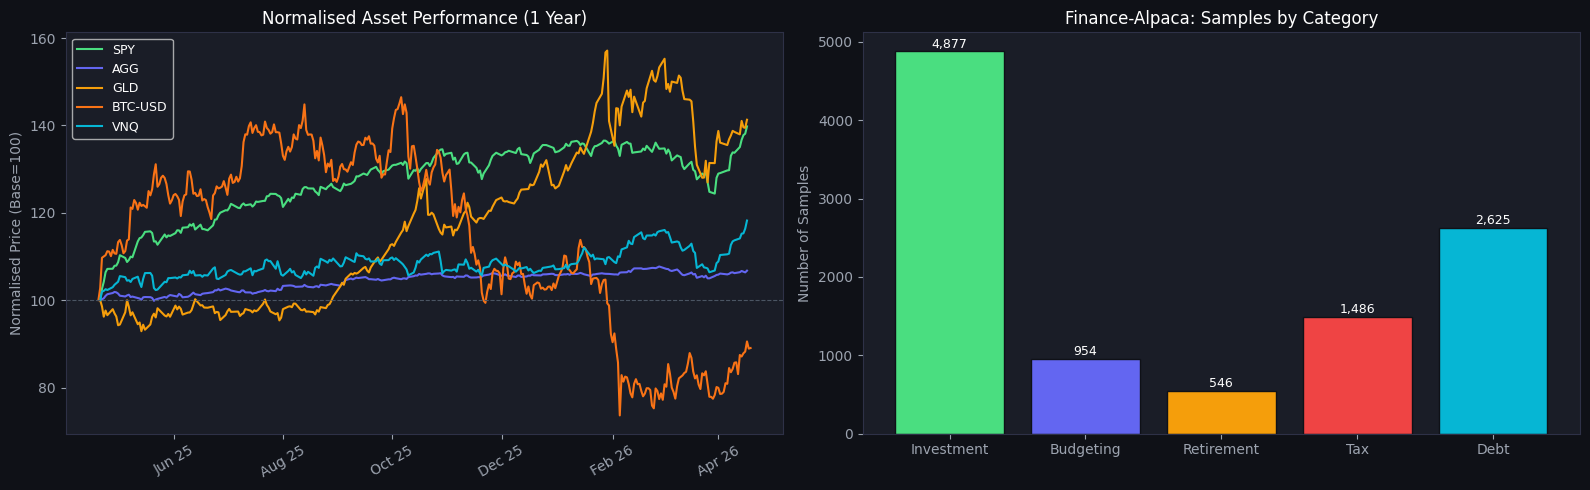


✅ Financial data collection chart saved.

📌 Market Context String (injected into LLM prompts):
Current Market Snapshot (live data):
  - S&P 500 ETF (Broad Market) (SPY): $710.14, 1Y Return: +39.8%, Volatility: 12.9%
  - Bond ETF (Fixed Income) (AGG): $99.85, 1Y Return: +6.8%, Volatility: 4.0%
  - Gold ETF (Commodity) (GLD): $445.93, 1Y Return: +41.3%, Volatility: 27.3%
  - Bitcoin (Crypto) (BTC-USD): $75840.40, 1Y Return: -11.0%, Volatility: 35.9%
  - Real Estate ETF (REIT) (VNQ): $96.68, 1Y Return: +18.2%, Volatility: 13.4%



In [23]:
# ============================================================
# Financial Data Collection — HuggingFace + Live Market Data
# ============================================================
%pip install -q yfinance datasets

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datasets import load_dataset
from datetime import datetime, timedelta

# ── PART 1: HuggingFace Finance-Alpaca Dataset ───────────────
print("=" * 60)
print("PART 1: HuggingFace Finance-Alpaca Dataset")
print("=" * 60)

fin_dataset = load_dataset("gbharti/finance-alpaca", split="train")
df_dataset  = fin_dataset.to_pandas()

print(f"✅ Dataset loaded: {len(df_dataset):,} samples")
print(f"   Columns: {list(df_dataset.columns)}")
print(f"\nSample Financial Instructions:")
for i, row in df_dataset.head(3).iterrows():
    print(f"  [{i+1}] {row['instruction'][:100]}...")

# Category distribution (based on keywords)
categories = {
    'Investment':  df_dataset['instruction'].str.contains('invest|stock|portfolio|ETF', case=False).sum(),
    'Budgeting':   df_dataset['instruction'].str.contains('budget|saving|spend|expense', case=False).sum(),
    'Retirement':  df_dataset['instruction'].str.contains('retire|401k|pension|superannuation', case=False).sum(),
    'Tax':         df_dataset['instruction'].str.contains('tax|deduction|capital gain', case=False).sum(),
    'Debt':        df_dataset['instruction'].str.contains('debt|loan|mortgage|credit', case=False).sum(),
}
print(f"\n📊 Dataset Category Distribution:")
for cat, count in categories.items():
    print(f"   {cat:<15}: {count:>5} samples")

# ── PART 2: Live Market Data via yfinance ─────────────────────
print("\n" + "=" * 60)
print("PART 2: Live Market Data (yfinance)")
print("=" * 60)

# Tickers representing typical financial planning asset classes
tickers = {
    'SPY':  'S&P 500 ETF (Broad Market)',
    'AGG':  'Bond ETF (Fixed Income)',
    'GLD':  'Gold ETF (Commodity)',
    'BTC-USD': 'Bitcoin (Crypto)',
    'VNQ':  'Real Estate ETF (REIT)',
}

end_date   = datetime.today()
start_date = end_date - timedelta(days=365)

price_data = {}
summary_rows = []

print(f"\nFetching 1-year price data ({start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')})...\n")

for ticker, label in tickers.items():
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not data.empty:
            close    = data['Close'].squeeze()
            ret_1yr  = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100
            volatility = close.pct_change().std() * (252 ** 0.5) * 100  # Annualised
            price_data[ticker] = close
            summary_rows.append({
                'Asset':       label,
                'Ticker':      ticker,
                'Latest Price': f"${close.iloc[-1]:.2f}",
                '1Y Return (%)': f"{ret_1yr:+.1f}%",
                'Volatility (%)': f"{volatility:.1f}%",
            })
            print(f"  ✅ {ticker:<8} | Price: ${close.iloc[-1]:<8.2f} | 1Y Return: {ret_1yr:+.1f}%")
        else:
            print(f"  ⚠️  {ticker}: No data returned")
    except Exception as e:
        print(f"  ❌ {ticker}: {e}")

# Summary table
df_summary = pd.DataFrame(summary_rows)
print("\n📊 Market Summary Table:")
print(df_summary.to_string(index=False))

# ── PART 3: Visualisation ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# Plot 1 — Normalised price performance
ax1 = axes[0]
ax1.set_facecolor('#1a1d27')
colors_map = {'SPY': '#4ade80', 'AGG': '#6366f1', 'GLD': '#f59e0b', 'BTC-USD': '#f97316', 'VNQ': '#06b6d4'}
for ticker, series in price_data.items():
    normalised = (series / series.iloc[0]) * 100
    ax1.plot(normalised.index, normalised.values,
             label=ticker, color=colors_map.get(ticker, '#ffffff'), linewidth=1.5)
ax1.axhline(100, color='#4b5563', linestyle='--', linewidth=0.8)
ax1.set_title('Normalised Asset Performance (1 Year)', color='white', fontsize=12)
ax1.set_ylabel('Normalised Price (Base=100)', color='#9ca3af')
ax1.tick_params(colors='#9ca3af')
ax1.spines[:].set_color('#2e3147')
ax1.legend(facecolor='#1a1d27', labelcolor='white', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, color='#9ca3af')

# Plot 2 — Dataset category bar chart
ax2 = axes[1]
ax2.set_facecolor('#1a1d27')
cat_colors = ['#4ade80', '#6366f1', '#f59e0b', '#ef4444', '#06b6d4']
bars = ax2.bar(categories.keys(), categories.values(), color=cat_colors, edgecolor='#0f1117')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height()):,}', ha='center', color='white', fontsize=9)
ax2.set_title('Finance-Alpaca: Samples by Category', color='white', fontsize=12)
ax2.set_ylabel('Number of Samples', color='#9ca3af')
ax2.tick_params(colors='#9ca3af')
ax2.spines[:].set_color('#2e3147')

plt.tight_layout()
plt.savefig('financial_data_collection.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n✅ Financial data collection chart saved.")

# ── PART 4: Inject live context into LLM prompt ──────────────
# Build a market context string that can be passed to FinBot
if summary_rows:
    market_context = "Current Market Snapshot (live data):\n"
    for row in summary_rows:
        market_context += f"  - {row['Asset']} ({row['Ticker']}): {row['Latest Price']}, 1Y Return: {row['1Y Return (%)']}, Volatility: {row['Volatility (%)']}\n"
    print("\n📌 Market Context String (injected into LLM prompts):")
    print(market_context)
else:
    market_context = ""
    print("⚠️  No live data available — market context will be empty.")


## Section 3: LLM-Driven Personal Assistant Dialogue System

This section implements a multi-turn financial dialogue system using LangChain.
The assistant collects the following information from the user:

1. **Task Definition** — What financial help does the user need?
2. **Personal Information** — Age, income, savings, employment status
3. **Financial Preferences** — Risk tolerance, investment goals, timeframe
4. **Enhanced Techniques** — Chain-of-Thought (CoT) prompting explored experimentally to improve recommendation structure

The selected model is `Qwen 2.5:3b`, deployed locally via Ollama, as required by the assignment specification. GPT-4o-mini is used only as a comparative benchmark in experimental sections of the notebook.

In [24]:
# ============================================================
# Financial Assistant Dialogue Chain
# ============================================================

from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import ChatMessageHistory

# System prompt with Chain-of-Thought (CoT) technique
system_prompt = """
You are FinBot, a smart and friendly personal financial assistant.
Your goal is to collect information from the user step by step and 
provide personalised financial strategies.

Follow this structured dialogue flow:
1. Greet the user and ask what financial help they need (task definition)
2. Collect personal details: age, annual income, current savings, employment status
3. Collect financial preferences: risk tolerance (low/moderate/high), 
   investment goals, and timeframe
4. Once all information is collected, use Chain-of-Thought reasoning:
   - Think through their financial situation step by step
   - Consider their risk tolerance and goals
   - Generate a structured, personalised financial strategy

Always be friendly, professional, and concise.
If the user has already provided some information, do not ask again.
When you have enough information, provide a structured recommendation with:
- Emergency Fund advice
- Investment Strategy
- Savings Plan
- Risk Management
- 10-year roadmap
"""

# Prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{input}")
])

# Chain
chain = prompt | llm_openai

# Session memory store
session_store = {}

def get_session_history(session_id: str) -> ChatMessageHistory:
    if session_id not in session_store:
        session_store[session_id] = ChatMessageHistory()
    return session_store[session_id]

# Runnable with memory
dialogue_chain = RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="history"
)

print("✅ Dialogue chain initialised successfully.")
print("✅ Chain-of-Thought (CoT) prompting applied.")
print("✅ Session memory configured.")

✅ Dialogue chain initialised successfully.
✅ Chain-of-Thought (CoT) prompting applied.
✅ Session memory configured.


In [25]:
# ============================================================
# Test Dialogue Chain (Sample Conversation)
# ============================================================

# Clear previous session memory before each test run
session_store.clear()

config = {"configurable": {"session_id": "test_session_1"}}

def chat(user_input, session_id="test_session_1"):
    config = {"configurable": {"session_id": session_id}}
    response = dialogue_chain.invoke(
        {"input": user_input},
        config=config
    )
    return response.content

# --- Simulated multi-turn conversation ---
turns = [
    "Hi, I need help with financial planning.",
    "I am 28 years old, I earn $75,000 a year and have $10,000 in savings.",
    "I have a moderate risk tolerance and want to grow my wealth over 10 years.",
    "I would also like to save for a house deposit.",
    "I am employed full-time."
]

print("🤖 FINBOT DIALOGUE DEMO")
print("=" * 60)

for user_msg in turns:
    print(f"\n👤 User: {user_msg}")
    response = chat(user_msg)
    print(f"\n🤖 FinBot: {response}")
    print("-" * 60)

🤖 FINBOT DIALOGUE DEMO

👤 User: Hi, I need help with financial planning.

🤖 FinBot: Hello! I'm here to help you with your financial planning. Could you please tell me what specific financial help you need? Are you looking for investment advice, savings strategies, or something else?
------------------------------------------------------------

👤 User: I am 28 years old, I earn $75,000 a year and have $10,000 in savings.

🤖 FinBot: Great, thank you for sharing that information! Now, could you please let me know your employment status? Are you currently employed full-time, part-time, or self-employed?
------------------------------------------------------------

👤 User: I have a moderate risk tolerance and want to grow my wealth over 10 years.

🤖 FinBot: Thank you for that information! Just to finalize, could you please share your current employment status? Are you employed full-time, part-time, or self-employed?
------------------------------------------------------------

👤 User: I wou

## Section 3 (Continued): LLM Techniques Summary

| Technique | Description | Applied In |
|---|---|---|
| **Chain-of-Thought (CoT)** | Step-by-step reasoning before answer (used experimentally to improve transparency and structure) | CoT comparison cell (Notebook1.ipynb) |
| **Prompt Engineering** | Structured role + task definition guiding financial reasoning | System prompt design |
| **Memory/History** | Multi-turn conversation context retained across messages | RunnableWithMessageHistory + ChatMessageHistory |
| **Temperature Control** | 0.1 for deterministic financial outputs in the main system; 0.7 used only in the post-finetuning inference test | LLM initialisation and finetuning evaluation |
| **Session Management** | In-memory session tracking for conversation continuity (prototype implementation) | RunnableWithMessageHistory (not Flask sessions) |

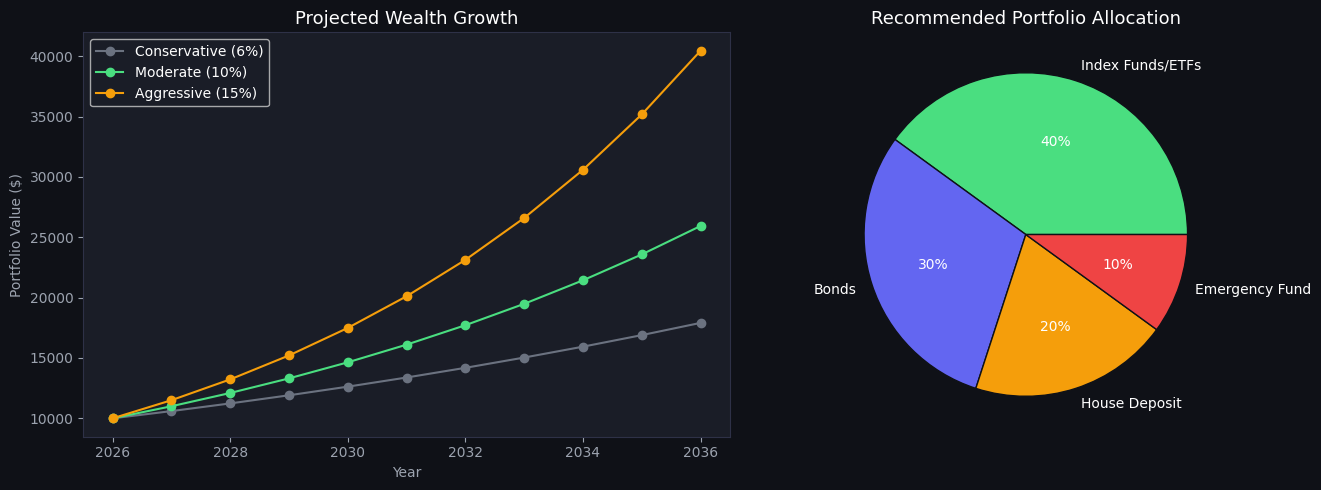

✅ Financial analysis chart saved.


In [26]:
# ============================================================
# Financial Data Collection & Visualisation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ── Sample Financial Data ────────────────────────────────────
years = np.arange(2026, 2037)

conservative = [10000 * (1.06 ** i) for i in range(11)]
moderate     = [10000 * (1.10 ** i) for i in range(11)]
aggressive   = [10000 * (1.15 ** i) for i in range(11)]

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

# Wealth Growth
ax1 = axes[0]
ax1.set_facecolor('#1a1d27')
ax1.plot(years, conservative, 'o-', color='#6b7280', label='Conservative (6%)')
ax1.plot(years, moderate,     'o-', color='#4ade80', label='Moderate (10%)')
ax1.plot(years, aggressive,   'o-', color='#f59e0b', label='Aggressive (15%)')
ax1.set_title('Projected Wealth Growth', color='white', fontsize=13)
ax1.set_xlabel('Year', color='#9ca3af')
ax1.set_ylabel('Portfolio Value ($)', color='#9ca3af')
ax1.tick_params(colors='#9ca3af')
ax1.legend(facecolor='#1a1d27', labelcolor='white')
ax1.spines[:].set_color('#2e3147')

# Portfolio Allocation
ax2 = axes[1]
ax2.set_facecolor('#1a1d27')
labels   = ['Index Funds/ETFs', 'Bonds', 'House Deposit', 'Emergency Fund']
sizes    = [40, 30, 20, 10]
colors   = ['#4ade80', '#6366f1', '#f59e0b', '#ef4444']
ax2.pie(sizes, labels=labels, colors=colors,
        autopct='%1.0f%%', textprops={'color': 'white'},
        wedgeprops={'edgecolor': '#0f1117'})
ax2.set_title('Recommended Portfolio Allocation', color='white', fontsize=13)

plt.tight_layout()
plt.savefig('financial_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Financial analysis chart saved.")